In [31]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s4e8/sample_submission.csv
/kaggle/input/playground-series-s4e8/train.csv
/kaggle/input/playground-series-s4e8/test.csv


In [32]:
import warnings
warnings.filterwarnings('ignore')

Loading the **train.csv** and **test.csv** files into pandas DataFrames, then truncating the training DataFrame to the first 600,000 rows to save computational time during model training, and finally displaying the truncated training DataFrame.

In [33]:
#importing Training and Testing Datasets
#Storing these datasets into Dataframes 
df_train = pd.read_csv("/kaggle/input/playground-series-s4e8/train.csv")
df_train = df_train.iloc[:600000,:]
df_test = pd.read_csv("/kaggle/input/playground-series-s4e8/test.csv")
df_train

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0,e,8.80,f,s,u,f,a,c,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,1,p,4.51,x,h,o,f,a,c,n,...,NaN,y,o,NaN,NaN,t,z,NaN,d,w
2,2,e,6.94,f,s,b,f,x,c,w,...,NaN,s,n,NaN,NaN,f,f,NaN,l,w
3,3,e,3.88,f,y,g,f,s,NaN,g,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
4,4,e,5.85,x,l,w,f,d,NaN,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,g,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,599995,e,7.73,x,s,n,f,e,c,p,...,NaN,i,n,NaN,NaN,f,f,p,d,w
599996,599996,p,11.23,x,t,n,f,a,d,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
599997,599997,p,1.50,o,k,n,f,NaN,NaN,n,...,NaN,NaN,n,NaN,NaN,f,f,NaN,d,a
599998,599998,p,7.09,x,s,n,f,s,NaN,n,...,NaN,y,n,NaN,NaN,f,f,NaN,d,w


In [34]:
#Droping the 'id' and 'class' columns from the training dataframe and
#Concating traing and testing Dataframes and 
#Storing these concated Dataframes into a Dataframe 'all_data'
all_data = pd.concat([df_train.drop(['id','class'], axis=1), df_test])

In [35]:
#Checking datatypes and memory usage info of the training data
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    600000 non-null  int64  
 1   class                 600000 non-null  object 
 2   cap-diameter          600000 non-null  float64
 3   cap-shape             599990 non-null  object 
 4   cap-surface           471041 non-null  object 
 5   cap-color             599999 non-null  object 
 6   does-bruise-or-bleed  599999 non-null  object 
 7   gill-attachment       498886 non-null  object 
 8   gill-spacing          358458 non-null  object 
 9   gill-color            599990 non-null  object 
 10  stem-height           600000 non-null  float64
 11  stem-width            600000 non-null  float64
 12  stem-root             69046 non-null   object 
 13  stem-surface          218539 non-null  object 
 14  stem-color            599993 non-null  object 
 15  

In [36]:
#Creating a function to reduce the memory usage by a given dataframe
def reduce_mem_usage(train_data):
    start_mem = train_data.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in train_data.columns:
        col_type = train_data[col].dtype

        if col_type != object:
            c_min = train_data[col].min()
            c_max = train_data[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    train_data[col] = train_data[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    train_data[col] = train_data[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    train_data[col] = train_data[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    train_data[col] = train_data[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    train_data[col] = train_data[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    train_data[col] = train_data[col].astype(np.float32)
                else:
                    train_data[col] = train_data[col].astype(np.float64)
        else:
            train_data[col] = train_data[col].astype('category')

    end_mem = train_data.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))

    return train_data

In [37]:
#Reducing the Memory usage by Traning data
df_train = reduce_mem_usage(df_train)

Memory usage of dataframe is 100.71 MB
Memory usage after optimization is: 16.04 MB
Decreased by 84.1%


In [38]:
#Reducing the Memory usage by Testing data
df_test = reduce_mem_usage(df_test)

Memory usage of dataframe is 332.93 MB
Memory usage after optimization is: 53.53 MB
Decreased by 83.9%


In [39]:
#Reducing the Memory usage by Concated data
all_data = reduce_mem_usage(all_data)

Memory usage of dataframe is 449.49 MB
Memory usage after optimization is: 89.41 MB
Decreased by 80.1%


In [40]:
#Understaning the Training Data
df_train.describe()

,id,cap-diameter,stem-height,stem-width
count,600000.000000,600000.000000,600000.000000,600000.000000
mean,299999.500000,NaN,NaN,NaN
std,173205.225094,0.000000,0.000000,0.000000
min,0.000000,0.409912,0.000000,0.000000
25%,149999.750000,3.310547,4.671875,4.968750
50%,299999.500000,5.750000,5.878906,9.640625
75%,449999.250000,8.226562,7.410156,15.617188
max,599999.000000,80.687500,57.218750,102.500000


In [41]:
#Droping 'id' column from Training dataframe and 'all_data'
df_train.drop("id", axis=1, inplace=True)
all_data.drop("id", axis=1, inplace=True)

In [42]:
#Creating a new dataframe that contains all the numerical columns of the Training data
df_num = df_train.select_dtypes(include=['number'])
df_num.head()

,cap-diameter,stem-height,stem-width
0,8.796875,4.511719,15.390625
1,4.511719,4.789062,6.480469
2,6.941406,6.851562,9.929688
3,3.880859,4.160156,6.531250
4,5.851562,3.369141,8.359375


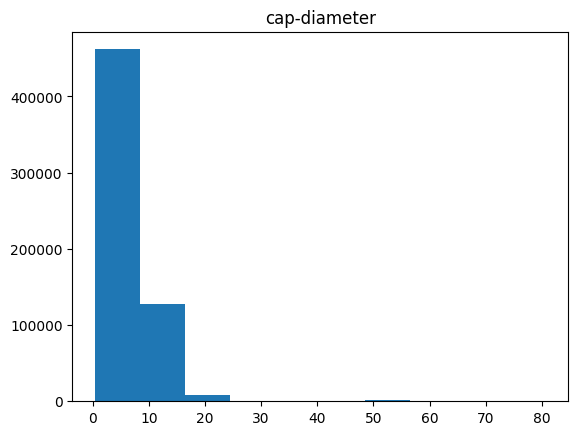

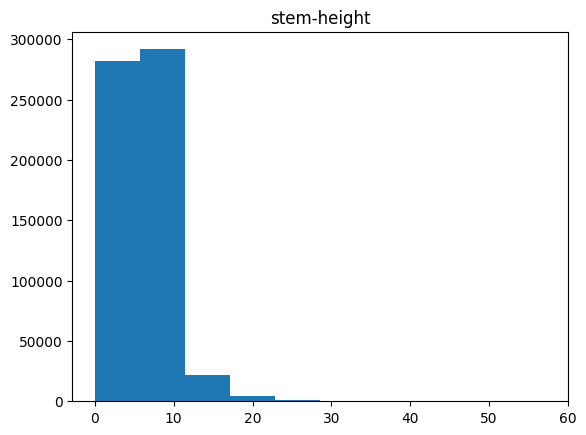

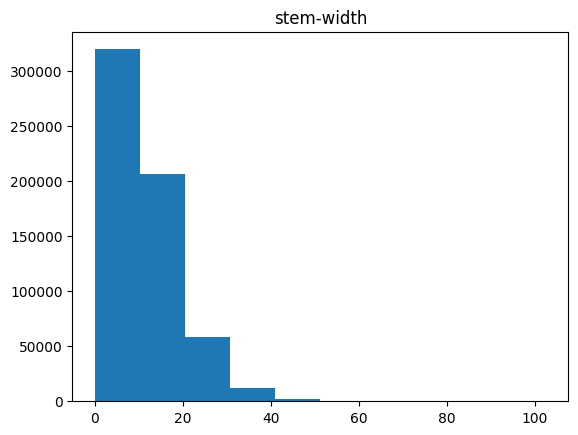

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

#Ploting Histograms of the column data of new numerical dataframe to understand the data distribution
for i in df_num.columns:
    plt.hist(df_num[i])
    plt.title(i)
    plt.show()

              cap-diameter  stem-height  stem-width
cap-diameter      1.000000     0.365829    0.746443
stem-height       0.365829     1.000000    0.356795
stem-width        0.746443     0.356795    1.000000


<Axes: >

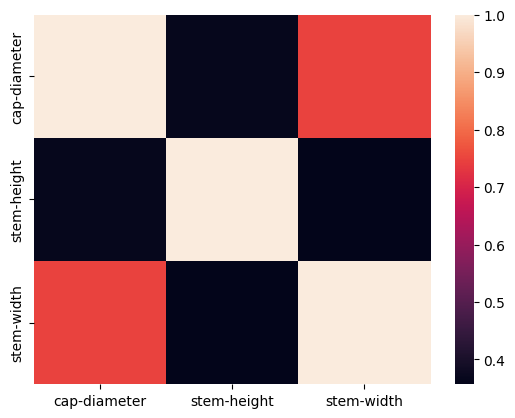

In [44]:
#Ploting the Heatmap of 'df_num' to understand the correlation between different variables
import seaborn as sns
print(df_num.corr())
sns.heatmap(df_num.corr())

In [45]:
#Grouping the data by 'Survived' column
pd.pivot_table(df_train, index='class', values = ['cap-diameter', 'stem-height', 'stem-width'])

,cap-diameter,stem-height,stem-width
class,,,
e,7.127136,6.495028,12.644745
p,5.617831,6.227690,9.897021


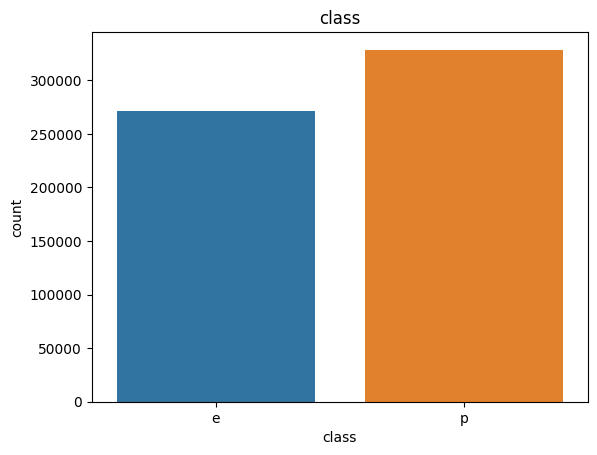

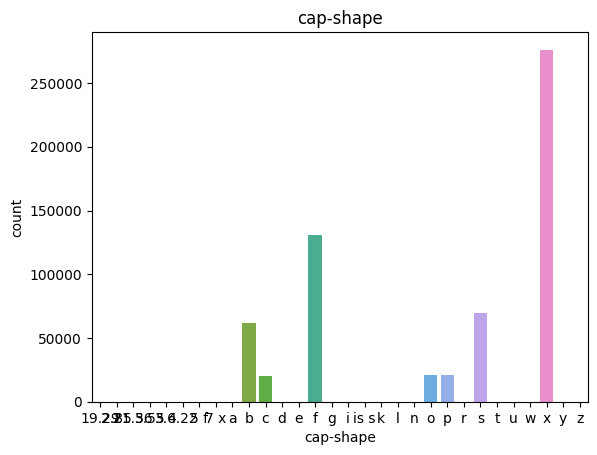

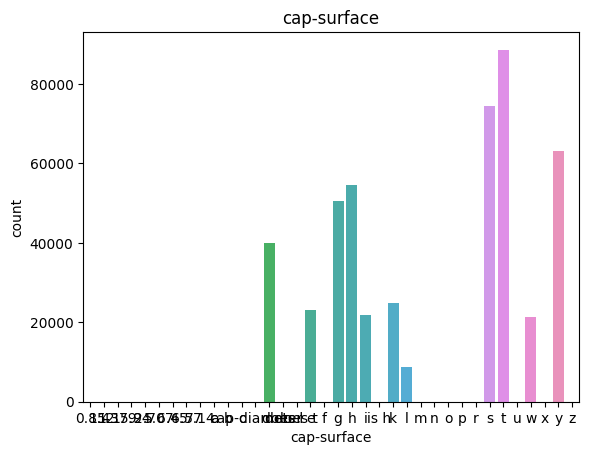

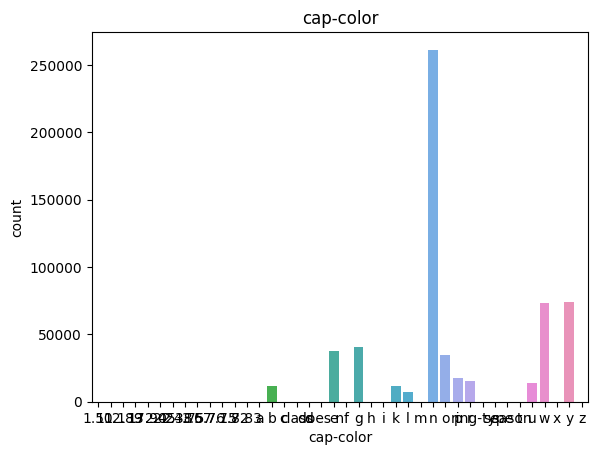

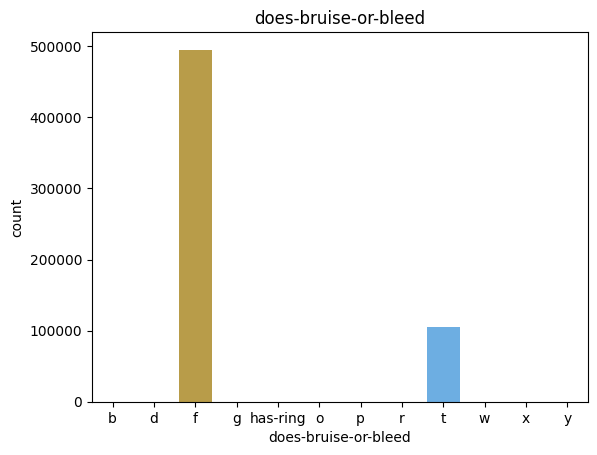

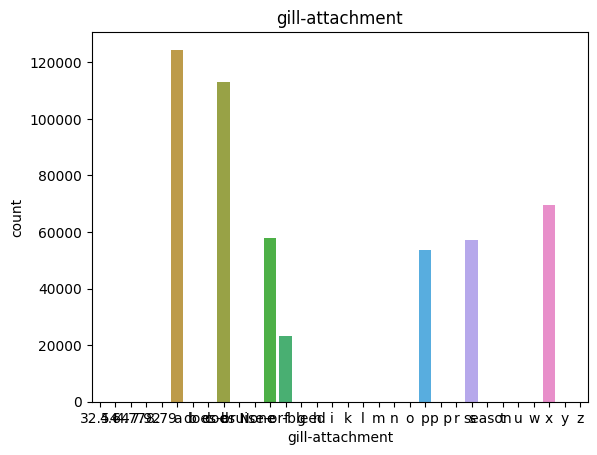

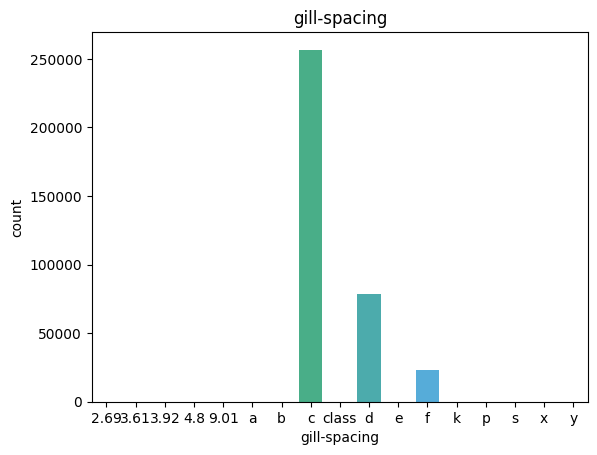

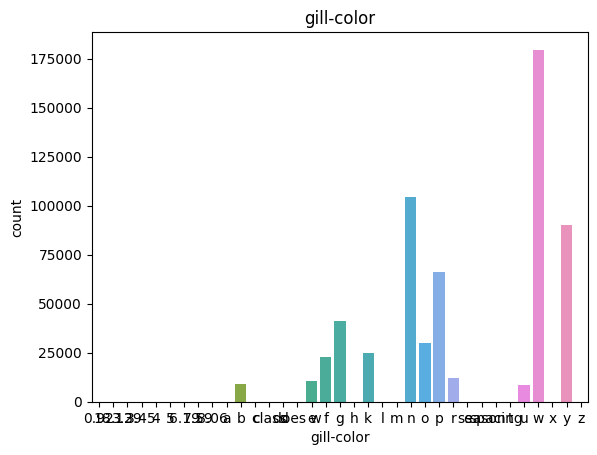

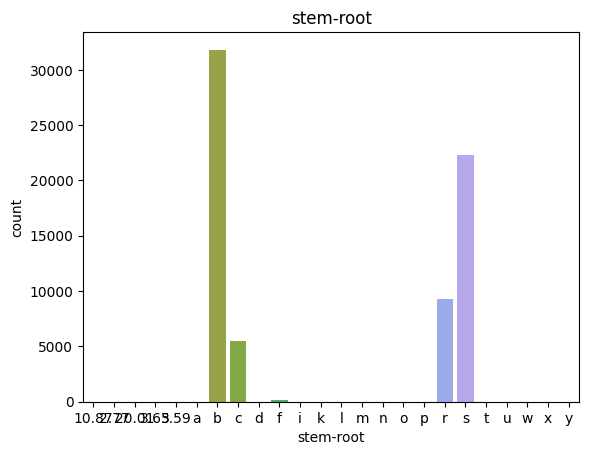

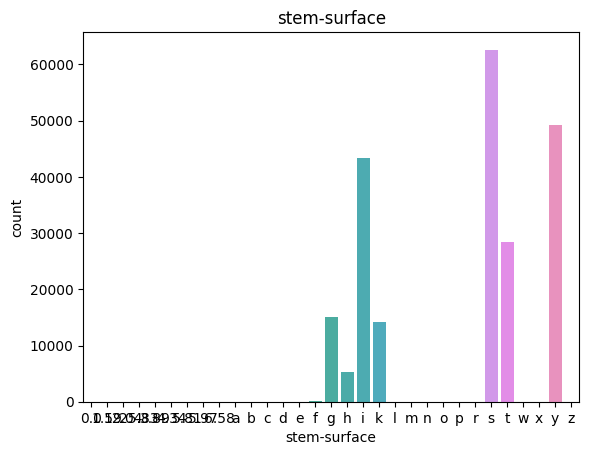

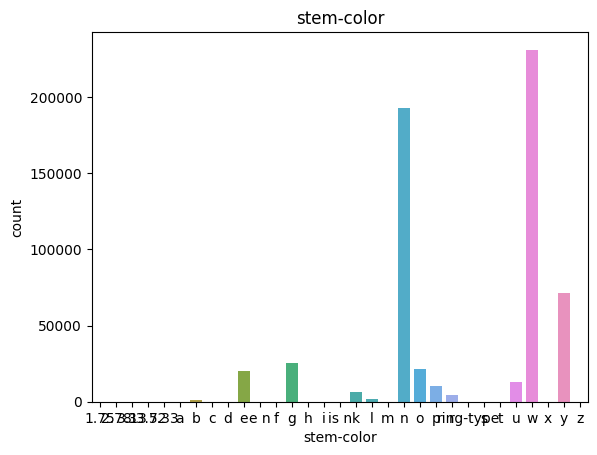

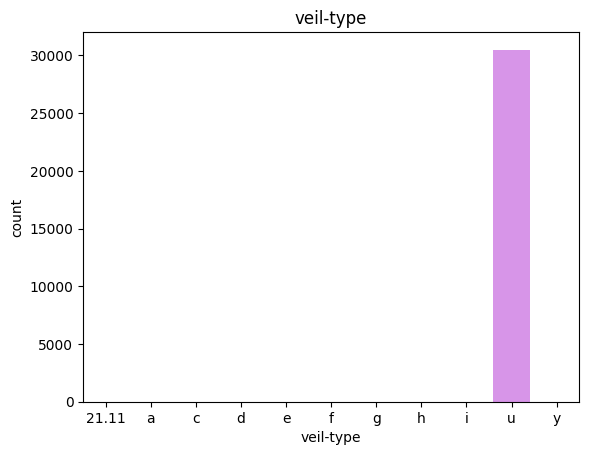

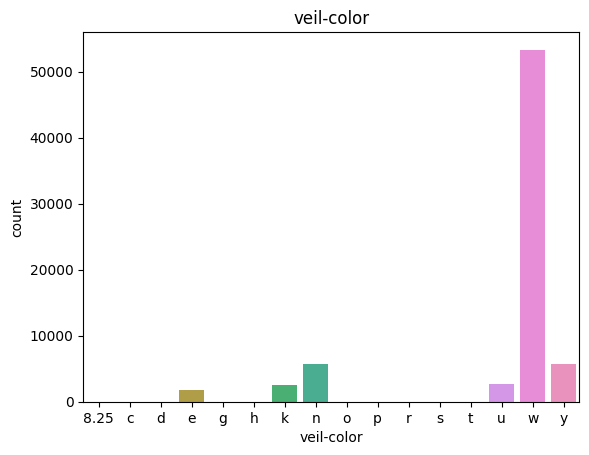

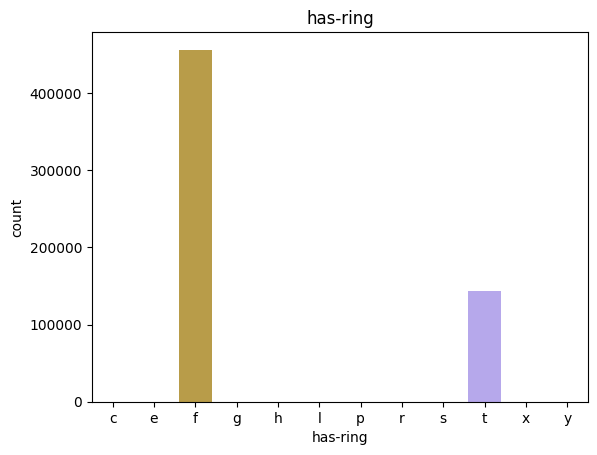

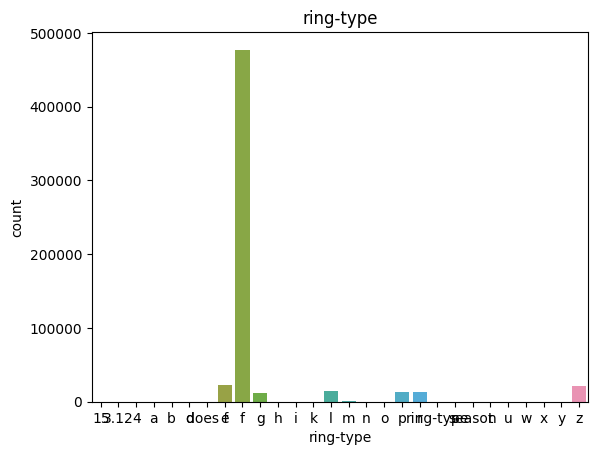

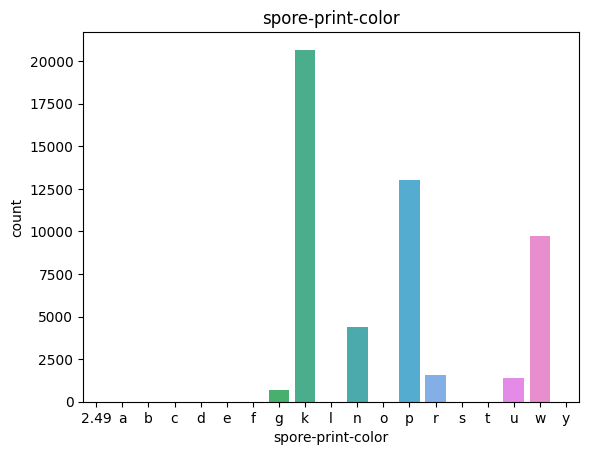

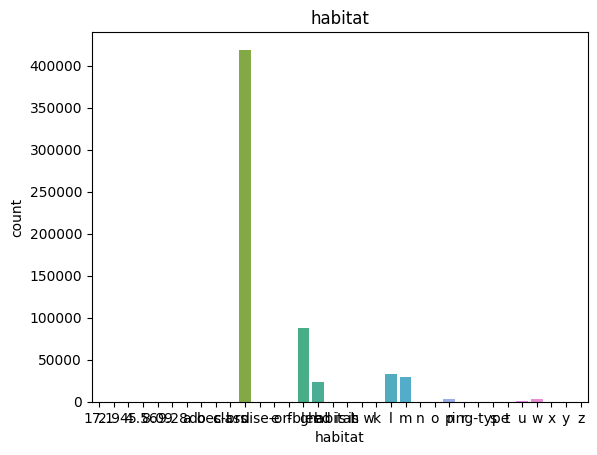

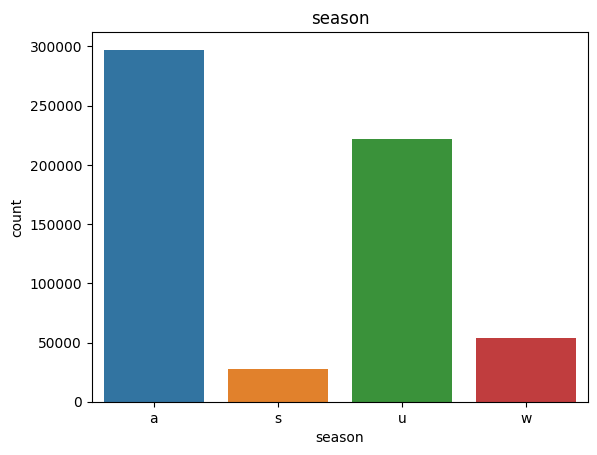

In [46]:
#Creating a new dataframe that contains all the categorical columns of the Training data
df_cat = df_train.select_dtypes(include=['category'])

#Ploting all the categorical columns as bar charts
for i in df_cat.columns:
    sns.barplot(x=df_cat[i].value_counts().index, y=df_cat[i].value_counts()).set_title(i)
    plt.show()

In [47]:
#Droping the 'veil-type' column as it contains a single (constant) value
all_data.drop("veil-type", axis=1, inplace=True)

In [48]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2677964 entries, 0 to 2077963
Data columns (total 19 columns):
 #   Column                Dtype   
---  ------                -----   
 0   cap-diameter          float16 
 1   cap-shape             category
 2   cap-surface           category
 3   cap-color             category
 4   does-bruise-or-bleed  category
 5   gill-attachment       category
 6   gill-spacing          category
 7   gill-color            category
 8   stem-height           float16 
 9   stem-width            float16 
 10  stem-root             category
 11  stem-surface          category
 12  stem-color            category
 13  veil-color            category
 14  has-ring              category
 15  ring-type             category
 16  spore-print-color     category
 17  habitat               category
 18  season                category
dtypes: category(16), float16(3)
memory usage: 76.6 MB


In [49]:
#print(all_data['cap-shape'].value_counts())

In [50]:
#value_counts = all_data['cap-shape'].value_counts()
#all_data = all_data[~all_data['cap-shape'].isin(value_counts[value_counts <= 10].index)]

In [51]:
#Replacing all the null values of the numerical columns of 'all_data' with Mode of the respective column
for col in all_data.select_dtypes(include=['number']).columns:
    print(all_data[col].isnull().value_counts())
    all_data[col].fillna(all_data[col].mode().values[0], inplace=True)
    print(all_data[col].isnull().value_counts())

cap-diameter
False    2677957
True           7
Name: count, dtype: int64
cap-diameter
False    2677964
Name: count, dtype: int64
stem-height
False    2677963
True           1
Name: count, dtype: int64
stem-height
False    2677964
Name: count, dtype: int64
stem-width
False    2677964
Name: count, dtype: int64
stem-width
False    2677964
Name: count, dtype: int64


In [52]:
#Replacing all the null values of the categorical columns of 'all_data' with Mode of the respective column
for col in all_data.select_dtypes(include=['category']).columns:
    print(all_data[col].isnull().value_counts())
    all_data[col].fillna(all_data[col].mode().values[0], inplace=True)
    print(all_data[col].isnull().value_counts())

cap-shape
False    2677923
True          41
Name: count, dtype: int64
cap-shape
False    2677964
Name: count, dtype: int64
cap-surface
False    2102101
True      575863
Name: count, dtype: int64
cap-surface
False    2677964
Name: count, dtype: int64
cap-color
False    2677950
True          14
Name: count, dtype: int64
cap-color
False    2677964
Name: count, dtype: int64
does-bruise-or-bleed
False    2677953
True          11
Name: count, dtype: int64
does-bruise-or-bleed
False    2677964
Name: count, dtype: int64
gill-attachment
False    2227029
True      450935
Name: count, dtype: int64
gill-attachment
False    2677964
Name: count, dtype: int64
gill-spacing
False    1596827
True     1081137
Name: count, dtype: int64
gill-spacing
False    2677964
Name: count, dtype: int64
gill-color
False    2677905
True          59
Name: count, dtype: int64
gill-color
False    2677964
Name: count, dtype: int64
stem-root
True     2368966
False     308998
Name: count, dtype: int64
stem-root
False    2677

In [53]:
#Create a new dataframe that stores the updated numerial and categorical columns of 'all_data'
all_updated = pd.concat([all_data.select_dtypes(include=['number']),pd.get_dummies(all_data.select_dtypes(include=['category']))], axis=1)

#Droping the columns with more than 99% False values
threshold=0.99
false_percentage = (all_updated == False).mean()
all_updated.drop(false_percentage[false_percentage >= threshold].index, axis=1, inplace=True)
all_updated.head()

,cap-diameter,stem-height,stem-width,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,...,spore-print-color_w,habitat_d,habitat_g,habitat_h,habitat_l,habitat_m,season_a,season_s,season_u,season_w
0,8.796875,4.511719,15.390625,False,False,True,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False
1,4.511719,4.789062,6.480469,False,False,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,True
2,6.941406,6.851562,9.929688,False,False,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,3.880859,4.160156,6.531250,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
4,5.851562,3.369141,8.359375,False,False,False,False,False,False,True,...,False,False,True,False,False,False,True,False,False,False


In [54]:
#Normalizing the data of 'all_updated' using StandardScaler
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
all_transformed = scale.fit_transform(all_updated)
all_transformed = pd.DataFrame(all_transformed, index=all_updated.index, columns=all_updated.columns)

In [55]:
#Splitting the all_transformed dataframe back to the Training and Testing dataframes
X_train = all_transformed.iloc[:len(df_train), :]
X_test = all_transformed.iloc[len(X_train):, :]
Y_train = df_train['class']

In [56]:
#Observing the first 5 rows of the X_train
X_train.head()

,cap-diameter,stem-height,stem-width,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,...,spore-print-color_w,habitat_d,habitat_g,habitat_h,habitat_l,habitat_m,season_a,season_s,season_u,season_w
0,0.532715,-0.679688,0.524414,-0.337158,-0.186035,1.895508,-0.189575,-0.188599,-0.363525,-0.924805,...,-0.128296,0.657715,-0.414062,-0.200195,-0.241577,-0.226196,1.009766,-0.218506,-0.765625,-0.313477
1,-0.383301,-0.577148,-0.576172,-0.337158,-0.186035,-0.527344,-0.189575,-0.188599,-0.363525,1.081055,...,-0.128296,0.657715,-0.414062,-0.200195,-0.241577,-0.226196,-0.990723,-0.218506,-0.765625,3.189453
2,0.136108,0.186768,-0.150269,-0.337158,-0.186035,1.895508,-0.189575,-0.188599,-0.363525,-0.924805,...,-0.128296,-1.520508,-0.414062,-0.200195,4.140625,-0.226196,-0.990723,-0.218506,-0.765625,3.189453
3,-0.518066,-0.810059,-0.569824,-0.337158,-0.186035,1.895508,-0.189575,-0.188599,-0.363525,-0.924805,...,-0.128296,0.657715,-0.414062,-0.200195,-0.241577,-0.226196,-0.990723,-0.218506,1.305664,-0.313477
4,-0.096924,-1.103516,-0.344238,-0.337158,-0.186035,-0.527344,-0.189575,-0.188599,-0.363525,1.081055,...,-0.128296,-1.520508,2.414062,-0.200195,-0.241577,-0.226196,1.009766,-0.218506,-0.765625,-0.313477


In [57]:
#Importing some useful functions from scikit-learn library
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [58]:
#Training and Checking Accuracy Score of Losgistic Regression Model on Training Data 
#using Cross Validation
lr = LogisticRegression(max_iter = 2000)
cv = cross_val_score(lr, X_train, Y_train, cv=5)
print(cv)
print(cv.mean())

[0.83380833 0.8344     0.83324167 0.834325   0.834     ]
0.8339549999999999


In [59]:
#Importing Random Forest Model
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state = 42)

In [61]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state = 1)
cv = cross_val_score(rf, X_train, Y_train, cv=5)
print(cv)
print(cv.mean())

[0.99103333 0.9915     0.99116667 0.99131667 0.99115   ]
0.9912333333333333


In [60]:
#Attempting to improve accuracy using GridSearchCV
#param_grid = {
#    'n_estimators': [100, 200],
#    'max_depth': [5, 10],
#    'min_samples_split': [2, 5],
#    'min_samples_leaf': [1, 2, 4],
#    'max_features': ['sqrt', 'log2']
#}
#grid_search = GridSearchCV(estimator=rf,param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
#rf_model = grid_search.fit(X_train, Y_train)
#rf_model.best_score_

#Discrded this entire code block as failed to improve the accuracy score

In [62]:
rf_model = rf.fit(X_train, Y_train)

In [63]:
#Predicting the Outcome for X_test Dataset and Exporting the Dataframe to .csv
Y_hat = rf_model.predict(X_test)
submission = {'id': df_test.id, 'class': Y_hat}
submission = pd.DataFrame(data=submission)
submission.to_csv('/kaggle/working/submission.csv', index=False)

**Conclusion:**

Achieved accuracy score of 0.98251 on Test Dataset using RandomForest ML model. Further attempt to improve the accuracy using GridSearchCV failed. Yet, there's still scope to improve the test accuracy by exploring other ML models and including more rows of training dataset for training.